# 01 — Análisis Exploratorio de Datos (EDA)
## Cross-Selling Recommender System | Instacart Market Basket Analysis

**Objetivo:** Entender la estructura, calidad y patrones del dataset Instacart para fundamentar las decisiones de modelado.

**Dataset:** Instacart Market Basket Analysis
- `orders.csv` — 3.4M órdenes de 206K usuarios
- `order_products__prior.csv` — 32.4M ítems (histórico de compras)
- `products.csv` — 49.7K productos
- `aisles.csv` — 134 pasillos
- `departments.csv` — 21 departamentos

**Secciones:**
1. Configuración e importaciones
2. Carga del dataset
3. Calidad de datos (nulos, outliers, duplicados)
4. Distribución de cestas
5. Análisis de productos (top, frecuencia, Zipf)
6. Patrones temporales (día de semana, hora del día)
7. Análisis de usuarios (actividad, recompras)
8. Análisis por departamento y pasillo
9. Correlaciones y heatmaps
10. Resumen de hallazgos

> **Nota metodológica:** Para el EDA se utiliza una muestra de 50.000 usuarios del histórico (`prior`),
> representativa de la distribución completa. Los modelos se entrenan sobre la muestra de 200.000 órdenes.


In [13]:
# ── 1. Configuración ────────────────────────────────────────────────────────
import sys
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

# Agregar raíz del proyecto al path
PROJECT_ROOT = Path().resolve().parents[1]  # notebooks/01_eda → raíz
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loader import load_config, load_instacart_tables

# Estilo visual
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
sns.set_palette("muted")
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Configuración lista")
print(f"   Figures → {FIGURES_DIR}")

✅ Configuración lista
   Figures → C:\Users\Angelica\PF_HENRY\Proyecto final de Henry\outputs\figures


---
## 2. Carga del Dataset

In [14]:
# ── 2. Carga del dataset ────────────────────────────────────────────────────
cfg = load_config()
orders, op_prior, products, aisles, departments = load_instacart_tables(cfg)

print("=== RESUMEN DE TABLAS ===")
tables = {
    "orders": orders,
    "order_products__prior": op_prior,
    "products": products,
    "aisles": aisles,
    "departments": departments,
}
for name, df in tables.items():
    mem = df.memory_usage(deep=True).sum() / 1e6
    print(f"  {name:<30} {len(df):>12,} filas | {len(df.columns):>2} cols | {mem:>7.1f} MB")

=== RESUMEN DE TABLAS ===
  orders                            3,421,083 filas |  7 cols |    54.7 MB
  order_products__prior            32,434,489 filas |  4 cols |   324.3 MB
  products                             49,688 filas |  4 cols |     4.7 MB
  aisles                                  134 filas |  2 cols |     0.0 MB
  departments                              21 filas |  2 cols |     0.0 MB


In [15]:
# Muestra de cada tabla
print("\n--- orders.csv ---")
display(orders.head(3))
print("\n--- order_products__prior.csv ---")
display(op_prior.head(3))
print("\n--- products.csv ---")
display(products.head(3))


--- orders.csv ---


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0



--- order_products__prior.csv ---


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0



--- products.csv ---


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7


---
## 3. Calidad de Datos

### 3.1 Valores faltantes

In [16]:
# ── 3.1 Valores faltantes ───────────────────────────────────────────────────
print("=== NULOS POR TABLA ===\n")
for name, df in tables.items():
    null_counts = df.isnull().sum()
    null_pcts   = (null_counts / len(df) * 100).round(2)
    if null_counts.sum() > 0:
        result = pd.DataFrame({"count": null_counts, "pct_%": null_pcts})
        result = result[result["count"] > 0]
        print(f"  {name}:")
        print(result.to_string())
        print()
    else:
        print(f"  {name}: ✅ Sin nulos")

=== NULOS POR TABLA ===

  orders:
                         count  pct_%
days_since_prior_order  206209   6.03

  order_products__prior: ✅ Sin nulos
  products: ✅ Sin nulos
  aisles: ✅ Sin nulos
  departments: ✅ Sin nulos


In [17]:
# Análisis de 'days_since_prior_order' (tiene NaN para primera orden)
null_days = orders["days_since_prior_order"].isnull()
print(f"Nulos en days_since_prior_order: {null_days.sum():,} ({null_days.mean()*100:.1f}%)")
print("→ Corresponde a la PRIMERA orden de cada usuario (esperado, no es error)")

# Confirmar: los nulos coinciden con order_number == 1
is_first_order = orders["order_number"] == 1
print(f"  Nulos = primera orden: {(null_days == is_first_order).all()}")

Nulos en days_since_prior_order: 206,209 (6.0%)
→ Corresponde a la PRIMERA orden de cada usuario (esperado, no es error)
  Nulos = primera orden: True


### 3.2 Duplicados

In [18]:
# ── 3.2 Duplicados ──────────────────────────────────────────────────────────
for name, df in tables.items():
    dup_count = df.duplicated().sum()
    status = "✅ Sin duplicados" if dup_count == 0 else f"⚠️  {dup_count:,} duplicados exactos"
    print(f"  {name:<30} {status}")

# Para order_products__prior: verificar duplicados por (order_id, product_id)
dup_pairs = op_prior.duplicated(subset=["order_id", "product_id"]).sum()
print(f"\n  order_products__prior: {dup_pairs:,} pares (order_id, product_id) duplicados")

  orders                         ✅ Sin duplicados
  order_products__prior          ✅ Sin duplicados
  products                       ✅ Sin duplicados
  aisles                         ✅ Sin duplicados
  departments                    ✅ Sin duplicados

  order_products__prior: 0 pares (order_id, product_id) duplicados


### 3.3 Tipos de datos y consistencia

In [19]:
# ── 3.3 Tipos y rangos ──────────────────────────────────────────────────────
print("=== RANGOS DE VALORES CLAVE ===")
print(f"  order_dow      : {orders['order_dow'].min()} – {orders['order_dow'].max()} (0=sáb, 6=vie)")
print(f"  order_hour     : {orders['order_hour_of_day'].min()} – {orders['order_hour_of_day'].max()}")
print(f"  order_number   : {orders['order_number'].min()} – {orders['order_number'].max()}")
print(f"  days_since     : {orders['days_since_prior_order'].min()} – {orders['days_since_prior_order'].max()}")
print(f"  reordered      : {sorted(op_prior['reordered'].unique())} (binario)")
print(f"\n  Usuarios únicos   : {orders['user_id'].nunique():,}")
print(f"  Productos únicos  : {products['product_id'].nunique():,}")
print(f"  Departamentos     : {departments['department_id'].nunique()}")
print(f"  Pasillos          : {aisles['aisle_id'].nunique()}")

=== RANGOS DE VALORES CLAVE ===
  order_dow      : 0 – 6 (0=sáb, 6=vie)
  order_hour     : 0 – 23
  order_number   : 1 – 100
  days_since     : 0.0 – 30.0
  reordered      : [0, 1] (binario)

  Usuarios únicos   : 206,209
  Productos únicos  : 49,688
  Departamentos     : 21
  Pasillos          : 134


---
## 4. Distribución de Cestas

La distribución del tamaño de cestas es fundamental para Association Rules:
si la mayoría de órdenes tiene solo 1 ítem, Apriori no puede generar pares.

=== ESTADÍSTICAS DE TAMAÑO DE CESTA ===
count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
90%      2.000000e+01
95%      2.500000e+01
99%      3.500000e+01
max      1.450000e+02


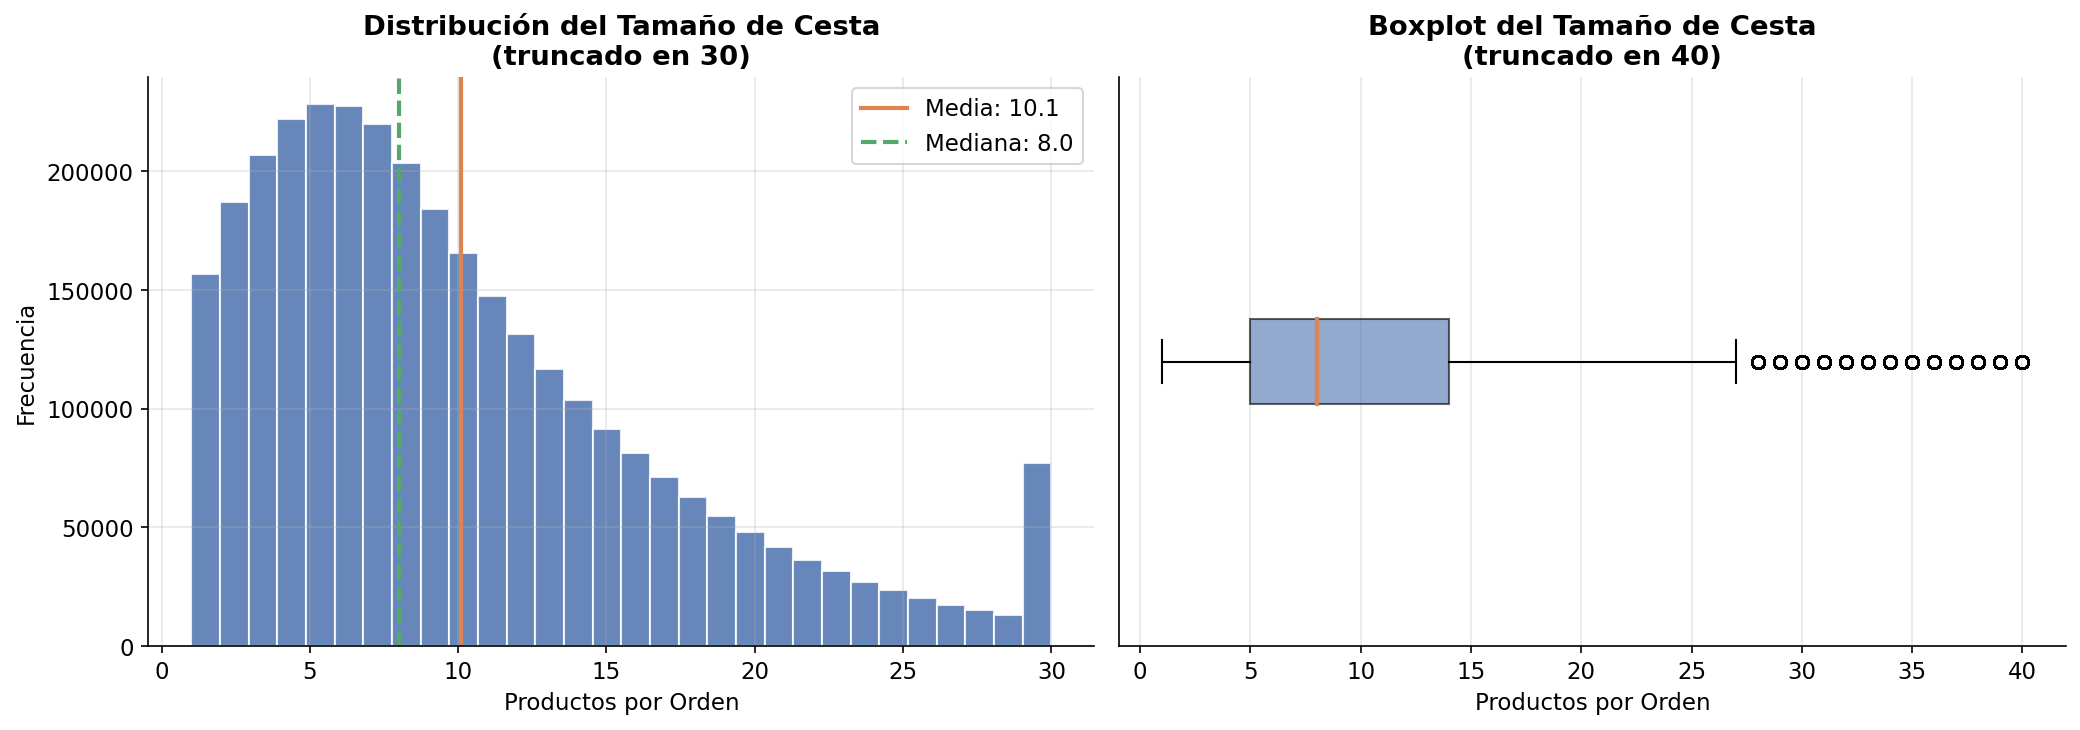


✅ Figura guardada en outputs/figures/
   Órdenes con >= 2 productos: 95.1% → APTO para Apriori


In [20]:
# ── 4. Distribución de cestas ───────────────────────────────────────────────
# Calcular tamaño de cada cesta (número de productos por orden)
basket_sizes = op_prior.groupby("order_id")["product_id"].nunique()

print("=== ESTADÍSTICAS DE TAMAÑO DE CESTA ===")
stats = basket_sizes.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
print(stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(basket_sizes.clip(upper=30), bins=30, color="#4C72B0", alpha=0.85, edgecolor="white")
axes[0].axvline(basket_sizes.mean(), color="#DD8452", lw=2, label=f"Media: {basket_sizes.mean():.1f}")
axes[0].axvline(basket_sizes.median(), color="#55A868", lw=2, ls="--", label=f"Mediana: {basket_sizes.median():.1f}")
axes[0].set_title("Distribución del Tamaño de Cesta\n(truncado en 30)", fontweight="bold")
axes[0].set_xlabel("Productos por Orden")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Boxplot
axes[1].boxplot(basket_sizes.clip(upper=40), vert=False, patch_artist=True,
                boxprops=dict(facecolor="#4C72B0", alpha=0.6),
                medianprops=dict(color="#DD8452", lw=2))
axes[1].set_title("Boxplot del Tamaño de Cesta\n(truncado en 40)", fontweight="bold")
axes[1].set_xlabel("Productos por Orden")
axes[1].set_yticks([])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_basket_size_distribution.png", bbox_inches="tight")
plt.show()
print(f"\n✅ Figura guardada en outputs/figures/")
print(f"   Órdenes con >= 2 productos: {(basket_sizes >= 2).mean()*100:.1f}% → APTO para Apriori")

---
## 5. Análisis de Productos

### 5.1 Distribución de frecuencias (Ley de Zipf)

In [21]:
# ── 5.1 Frecuencia de productos — Ley de Zipf ───────────────────────────────
product_freq_named = (
    op_prior["product_id"]
    .value_counts()
    .reset_index(name="count") # El conteo se llamará "count"
)

product_freq_named = product_freq_named.merge(
    products[["product_id", "product_name"]], 
    on="product_id", 
    how="left"
)

print(f"=== TOP 20 PRODUCTOS MÁS COMPRADOS ===")
print(product_freq_named.head(20)[["product_name", "count"]].to_string(index=False))

=== TOP 20 PRODUCTOS MÁS COMPRADOS ===
            product_name  count
                  Banana 472565
  Bag of Organic Bananas 379450
    Organic Strawberries 264683
    Organic Baby Spinach 241921
    Organic Hass Avocado 213584
         Organic Avocado 176815
             Large Lemon 152657
            Strawberries 142951
                   Limes 140627
      Organic Whole Milk 137905
     Organic Raspberries 137057
    Organic Yellow Onion 113426
          Organic Garlic 109778
        Organic Zucchini 104823
     Organic Blueberries 100060
          Cucumber Kirby  97315
      Organic Fuji Apple  89632
           Organic Lemon  87746
Apple Honeycrisp Organic  85020
  Organic Grape Tomatoes  84255


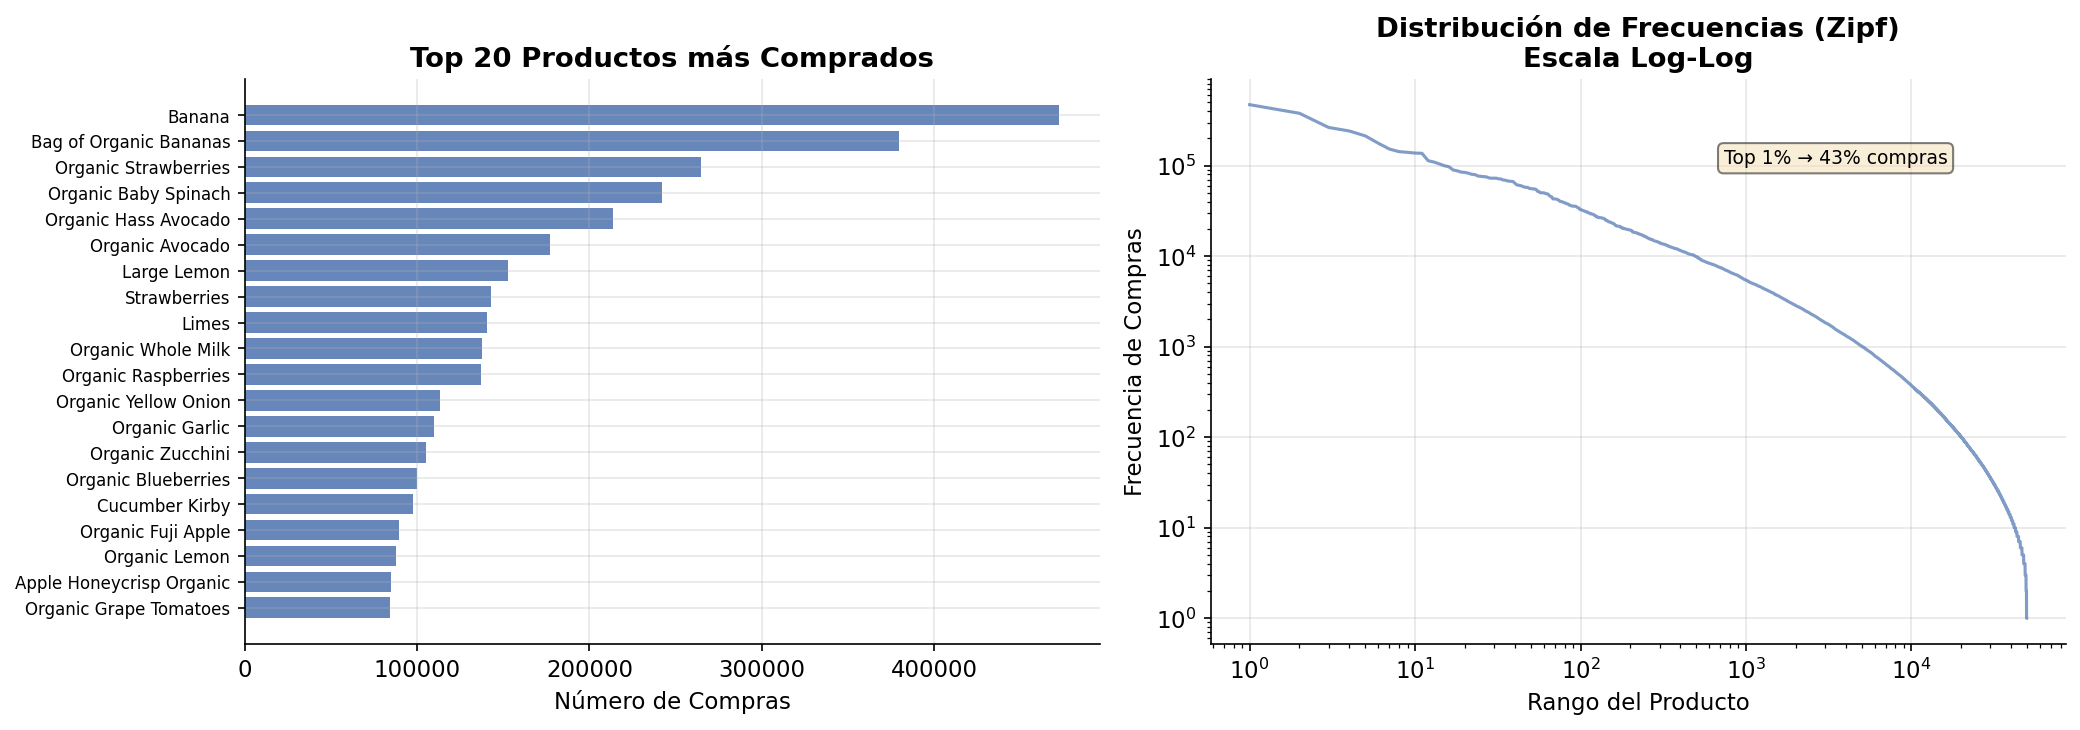

In [22]:
# Gráfico Zipf: frecuencia vs rango en escala log-log
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 20 productos (barras)
top20 = product_freq_named.head(20)
axes[0].barh(top20["product_name"].str[:35][::-1], top20["count"][::-1],
             color="#4C72B0", alpha=0.85)
axes[0].set_title("Top 20 Productos más Comprados", fontweight="bold")
axes[0].set_xlabel("Número de Compras")
axes[0].tick_params(axis='y', labelsize=8)

# Distribución Zipf (log-log)
ranks = np.arange(1, len(product_freq) + 1)
axes[1].loglog(ranks, product_freq.values, alpha=0.7, color="#4C72B0", lw=1.5)
axes[1].set_title("Distribución de Frecuencias (Zipf)\nEscala Log-Log", fontweight="bold")
axes[1].set_xlabel("Rango del Producto")
axes[1].set_ylabel("Frecuencia de Compras")
axes[1].text(0.6, 0.85,
             f"Top 1% → {(product_freq.values[:int(len(product_freq)*0.01)].sum()/product_freq.sum()*100):.0f}% compras",
             transform=axes[1].transAxes, fontsize=9,
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_product_frequency_zipf.png", bbox_inches="tight")
plt.show()

### 5.2 Tasa de recompra por producto

Tasa de recompra global: 59.0%
Productos con tasa > 80%: 248


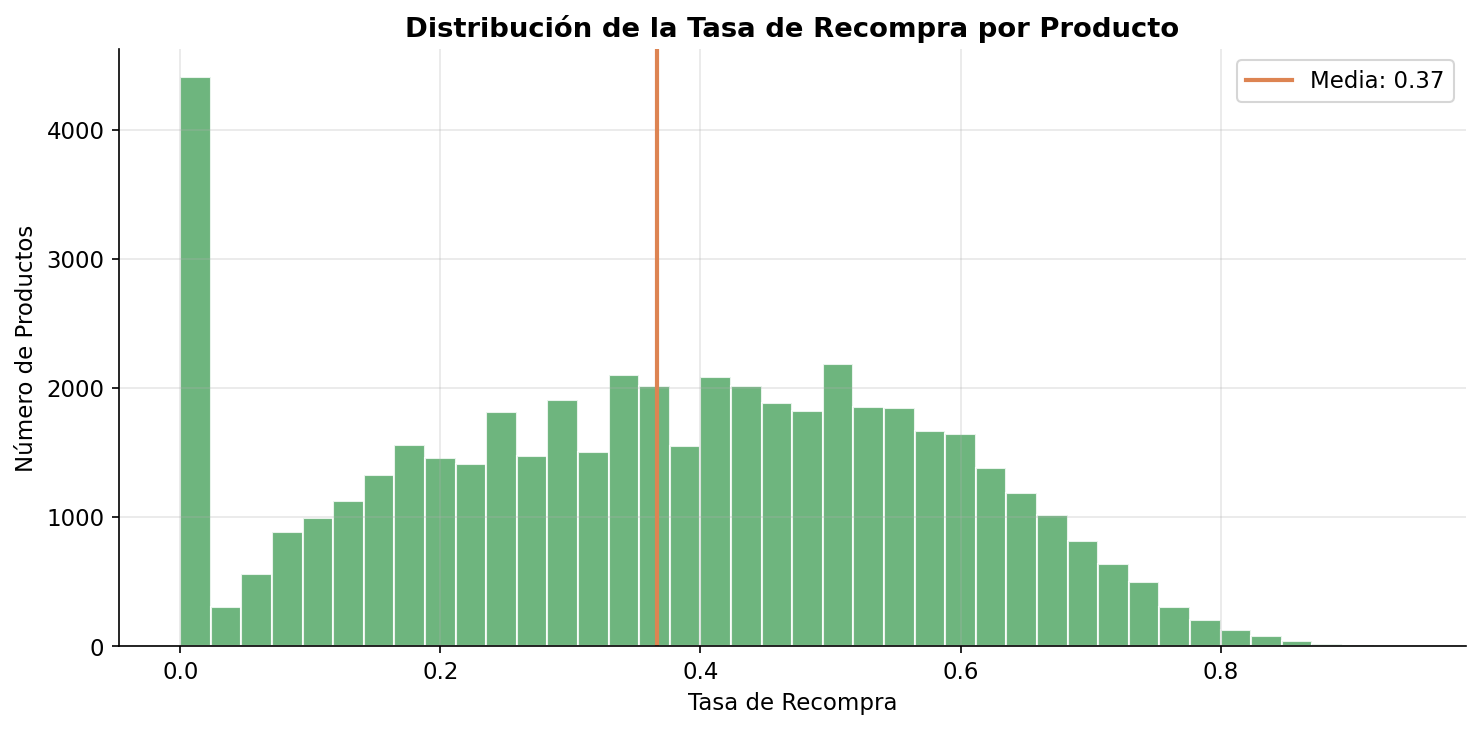

In [23]:
# ── 5.2 Tasa de recompra ────────────────────────────────────────────────────
reorder_by_product = (
    op_prior.groupby("product_id")["reordered"]
    .agg(total_purchases="count", reorders="sum")
    .assign(reorder_rate=lambda x: x["reorders"] / x["total_purchases"])
    .merge(products[["product_id", "product_name", "department_id"]], on="product_id", how="left")
    .sort_values("total_purchases", ascending=False)
)

print(f"Tasa de recompra global: {op_prior['reordered'].mean()*100:.1f}%")
print(f"Productos con tasa > 80%: {(reorder_by_product['reorder_rate'] > 0.8).sum():,}")

# Distribución de tasas de recompra
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(reorder_by_product["reorder_rate"], bins=40, color="#55A868", alpha=0.85, edgecolor="white")
ax.axvline(reorder_by_product["reorder_rate"].mean(), color="#DD8452", lw=2,
           label=f"Media: {reorder_by_product['reorder_rate'].mean():.2f}")
ax.set_title("Distribución de la Tasa de Recompra por Producto", fontweight="bold")
ax.set_xlabel("Tasa de Recompra")
ax.set_ylabel("Número de Productos")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_reorder_rate_distribution.png", bbox_inches="tight")
plt.show()

---
## 6. Patrones Temporales

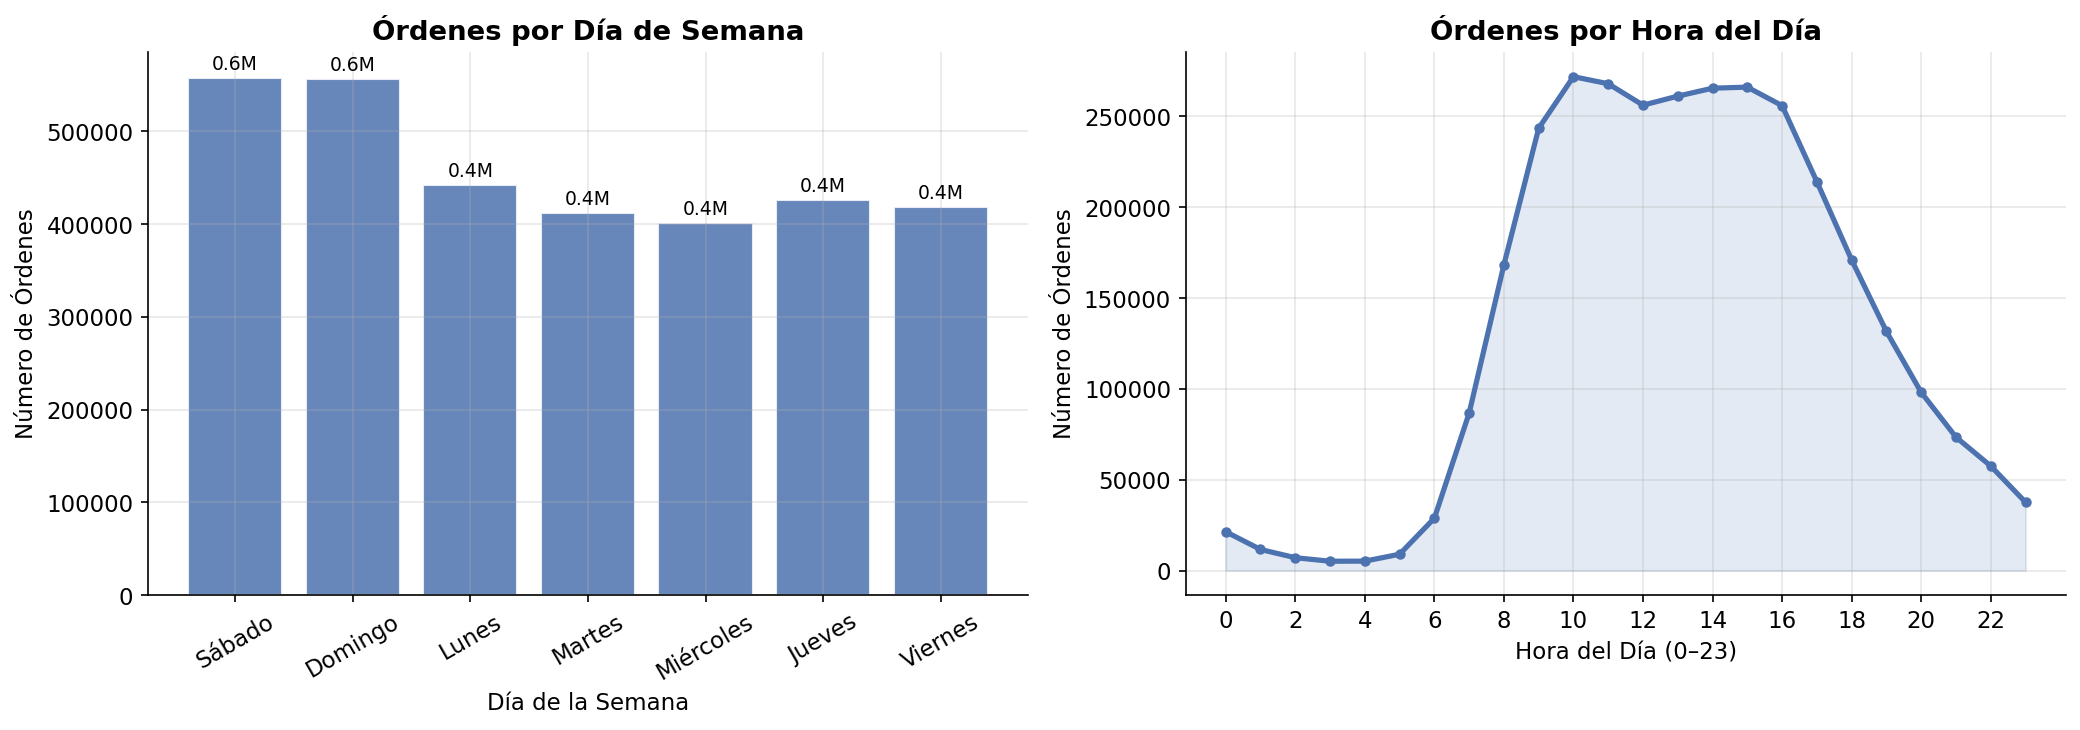

In [24]:
# ── 6. Patrones temporales ──────────────────────────────────────────────────
dow_names = {0: "Sábado", 1: "Domingo", 2: "Lunes", 3: "Martes",
             4: "Miércoles", 5: "Jueves", 6: "Viernes"}

orders_with_info = orders[orders["eval_set"] == "prior"].copy()
orders_with_info["day_name"] = orders_with_info["order_dow"].map(dow_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por día de semana
dow_counts = orders_with_info["order_dow"].value_counts().sort_index()
dow_labels = [dow_names[i] for i in dow_counts.index]
bars = axes[0].bar(dow_labels, dow_counts.values, color="#4C72B0", alpha=0.85, edgecolor="white")
axes[0].set_title("Órdenes por Día de Semana", fontweight="bold")
axes[0].set_xlabel("Día de la Semana")
axes[0].set_ylabel("Número de Órdenes")
axes[0].tick_params(axis="x", rotation=30)
for bar, val in zip(bars, dow_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f"{val/1e6:.1f}M", ha="center", va="bottom", fontsize=9)

# Por hora del día
hour_counts = orders_with_info["order_hour_of_day"].value_counts().sort_index()
axes[1].plot(hour_counts.index, hour_counts.values, color="#4C72B0", lw=2.5, marker="o", ms=4)
axes[1].fill_between(hour_counts.index, hour_counts.values, alpha=0.15, color="#4C72B0")
axes[1].set_title("Órdenes por Hora del Día", fontweight="bold")
axes[1].set_xlabel("Hora del Día (0–23)")
axes[1].set_ylabel("Número de Órdenes")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_temporal_patterns.png", bbox_inches="tight")
plt.show()

---
## 7. Análisis de Usuarios

=== ESTADÍSTICAS DE ACTIVIDAD DE USUARIOS ===
        n_orders  avg_days_between
count  206209.00         206209.00
mean       15.59             15.21
std        16.65              7.11
min         3.00              0.00
25%         5.00              9.42
50%         9.00             14.50
75%        19.00             20.29
95%        51.00             29.00
max        99.00             30.00


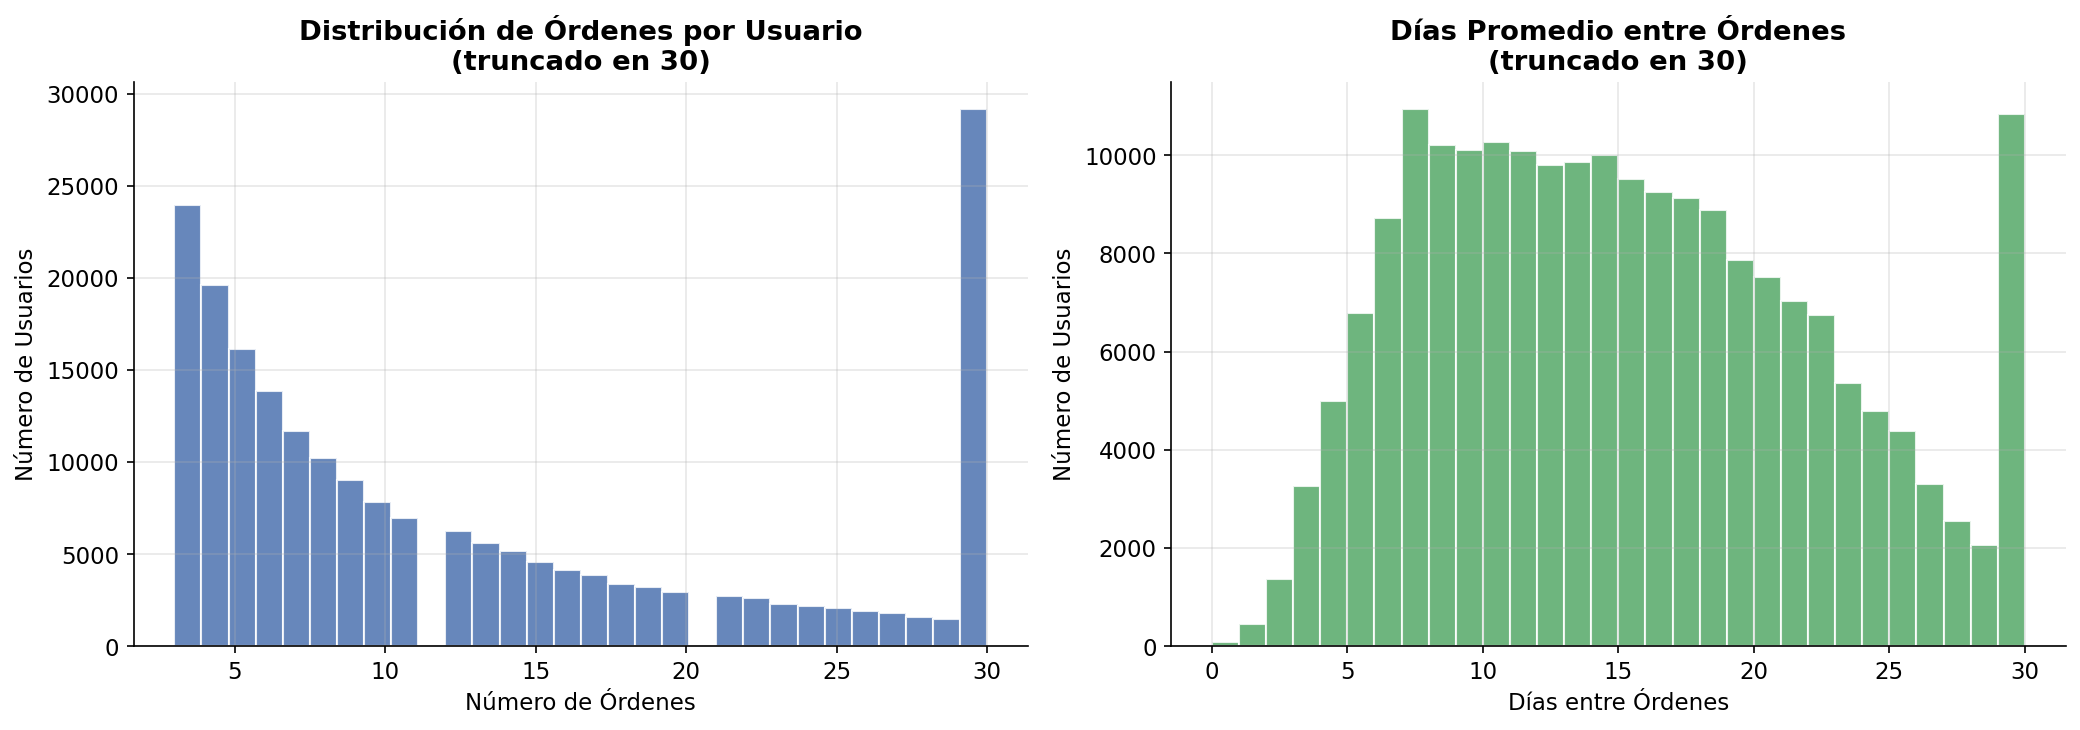

In [25]:
# ── 7. Actividad de usuarios ────────────────────────────────────────────────
user_stats = (
    orders[orders["eval_set"] == "prior"]
    .groupby("user_id")
    .agg(
        n_orders=("order_id", "nunique"),
        avg_days_between=("days_since_prior_order", "mean"),
    )
)

print("=== ESTADÍSTICAS DE ACTIVIDAD DE USUARIOS ===")
print(user_stats.describe(percentiles=[0.25, 0.5, 0.75, 0.95]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de órdenes por usuario
axes[0].hist(user_stats["n_orders"].clip(upper=30), bins=30,
             color="#4C72B0", alpha=0.85, edgecolor="white")
axes[0].set_title("Distribución de Órdenes por Usuario\n(truncado en 30)", fontweight="bold")
axes[0].set_xlabel("Número de Órdenes")
axes[0].set_ylabel("Número de Usuarios")

# Distribución de días entre órdenes
axes[1].hist(user_stats["avg_days_between"].dropna().clip(upper=30), bins=30,
             color="#55A868", alpha=0.85, edgecolor="white")
axes[1].set_title("Días Promedio entre Órdenes\n(truncado en 30)", fontweight="bold")
axes[1].set_xlabel("Días entre Órdenes")
axes[1].set_ylabel("Número de Usuarios")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_user_activity.png", bbox_inches="tight")
plt.show()

---
## 8. Análisis por Departamento y Pasillo

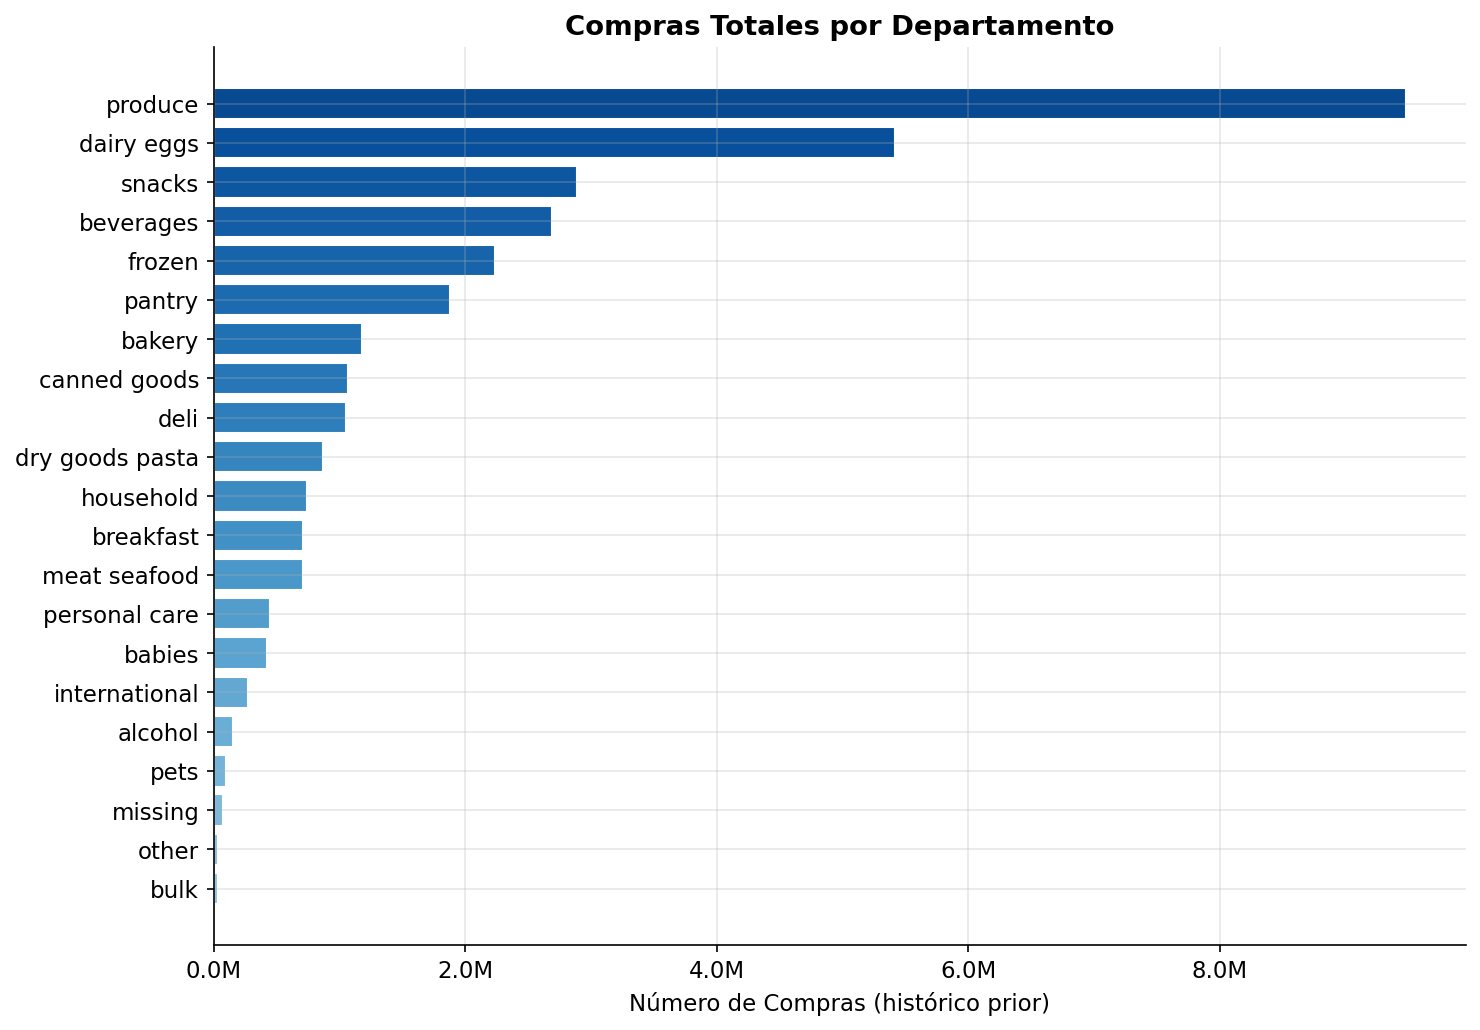

In [26]:
# ── 8. Departamentos ────────────────────────────────────────────────────────
# Unir productos con departamentos
products_full = products.merge(departments, on="department_id").merge(aisles, on="aisle_id")

dept_sales = (
    op_prior
    .merge(products[["product_id", "department_id"]], on="product_id")
    .merge(departments, on="department_id")
    .groupby("department")
    .size()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(dept_sales)))
bars = ax.barh(dept_sales.index, dept_sales.values, color=colors, edgecolor="white")
ax.set_title("Compras Totales por Departamento", fontweight="bold")
ax.set_xlabel("Número de Compras (histórico prior)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_department_sales.png", bbox_inches="tight")
plt.show()

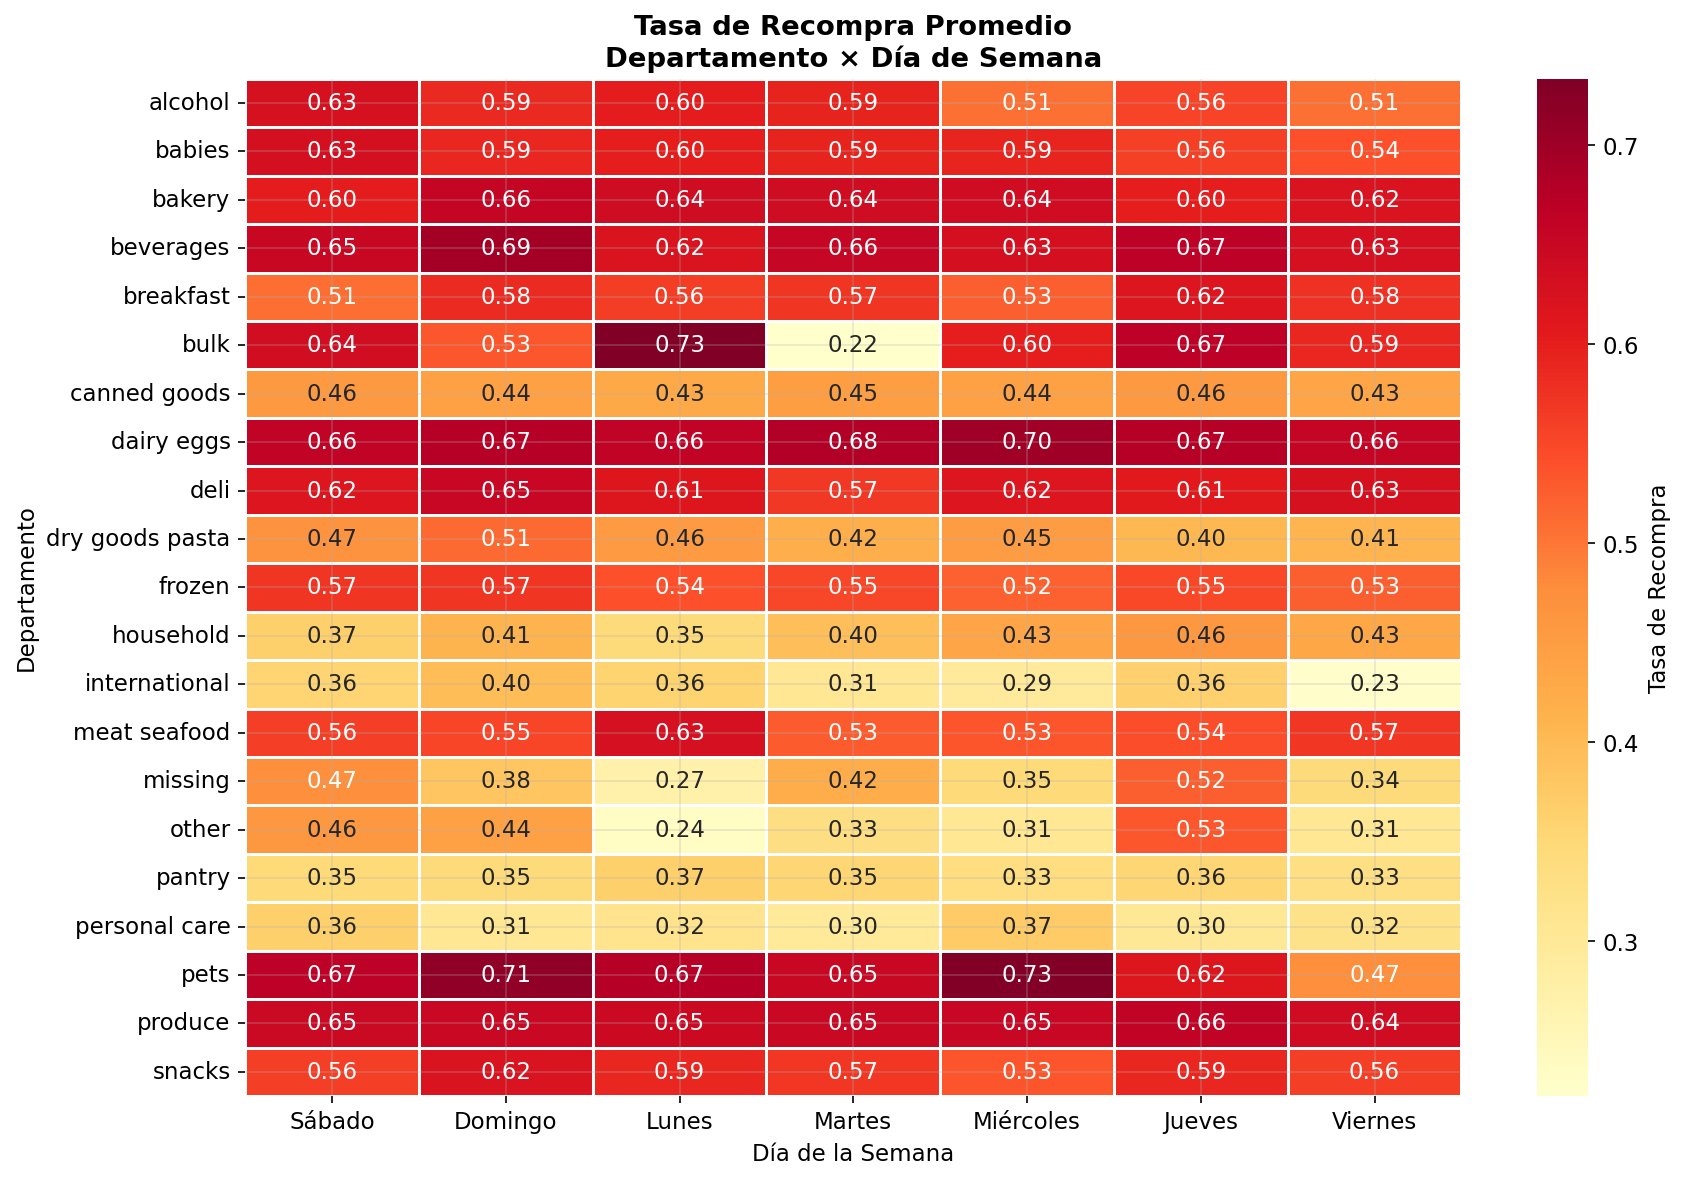

In [27]:
# Heatmap: tasa de recompra promedio por departamento × día de semana
# (muestra de 100K filas para eficiencia)
sample_ops = op_prior.sample(n=100_000, random_state=42)
heatmap_data = (
    sample_ops
    .merge(orders[["order_id", "order_dow"]], on="order_id")
    .merge(products[["product_id", "department_id"]], on="product_id")
    .merge(departments, on="department_id")
    .groupby(["department", "order_dow"])["reordered"]
    .mean()
    .unstack(fill_value=0)
)
heatmap_data.columns = [dow_names[c] for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Tasa de Recompra"})
ax.set_title("Tasa de Recompra Promedio\nDepartamento × Día de Semana", fontweight="bold")
ax.set_xlabel("Día de la Semana")
ax.set_ylabel("Departamento")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_reorder_heatmap_dept_dow.png", bbox_inches="tight")
plt.show()

---
## 9. Correlaciones y Análisis de Co-compra

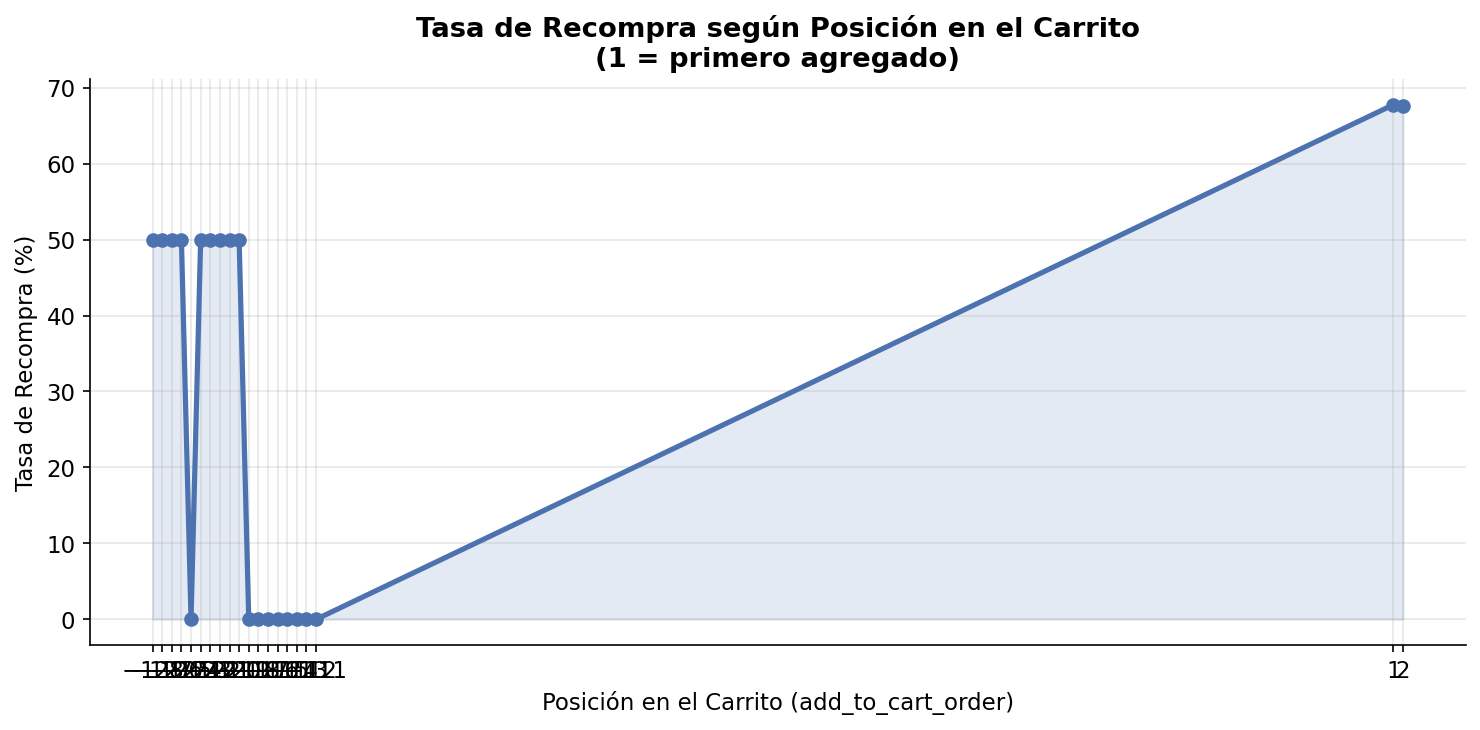

Insight: Los primeros ítems del carrito tienen mayor tasa de recompra.
→ Son los 'ítems ancla' del usuario (favoritos/habituales).
→ Los ítems en posición 5+ son más exploratorios → mayor potencial de cross-selling


In [28]:
# ── 9. Posición en carrito y recompra ───────────────────────────────────────
# ¿Los ítems que se agregan primero al carrito tienen mayor tasa de recompra?
cart_reorder = (
    op_prior
    .groupby("add_to_cart_order")["reordered"]
    .agg(mean_reorder="mean", count="count")
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cart_reorder.index, cart_reorder["mean_reorder"] * 100,
        marker="o", lw=2.5, color="#4C72B0", ms=6)
ax.fill_between(cart_reorder.index, cart_reorder["mean_reorder"] * 100,
                alpha=0.15, color="#4C72B0")
ax.set_title("Tasa de Recompra según Posición en el Carrito\n(1 = primero agregado)",
             fontweight="bold")
ax.set_xlabel("Posición en el Carrito (add_to_cart_order)")
ax.set_ylabel("Tasa de Recompra (%)")
ax.set_xticks(cart_reorder.index)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_cart_position_vs_reorder.png", bbox_inches="tight")
plt.show()

print("Insight: Los primeros ítems del carrito tienen mayor tasa de recompra.")
print("→ Son los 'ítems ancla' del usuario (favoritos/habituales).")
print("→ Los ítems en posición 5+ son más exploratorios → mayor potencial de cross-selling")

---
## 10. Resumen de Hallazgos

In [29]:
# ── 10. Resumen ─────────────────────────────────────────────────────────────
print("=" * 60)
print("RESUMEN EDA — INSTACART MARKET BASKET ANALYSIS")
print("=" * 60)

n_users   = orders["user_id"].nunique()
n_orders  = len(orders[orders["eval_set"] == "prior"])
n_items   = len(op_prior)
n_prod    = products["product_id"].nunique()
reorder   = op_prior["reordered"].mean() * 100
bs_mean   = op_prior.groupby("order_id")["product_id"].nunique().mean()
bs_med    = op_prior.groupby("order_id")["product_id"].nunique().median()
top1_conc = (product_freq.values[:int(len(product_freq)*0.01)].sum() / product_freq.sum() * 100)

print(f"\n  📊 Escala del dataset")
print(f"     Usuarios únicos      : {n_users:>12,}")
print(f"     Órdenes (prior)      : {n_orders:>12,}")
print(f"     Ítems totales        : {n_items:>12,}")
print(f"     Productos en catálogo: {n_prod:>12,}")
print(f"\n  🛒 Comportamiento de compra")
print(f"     Tamaño de cesta (media)   : {bs_mean:.1f} productos/orden")
print(f"     Tamaño de cesta (mediana) : {bs_med:.0f} productos/orden")
print(f"     Tasa de recompra global   : {reorder:.1f}%")
print(f"     Concentración (top 1%)    : {top1_conc:.0f}% de las compras")
print(f"\n  ✅ Decisiones validadas por el EDA")
print(f"     FP-Growth viable   : Cesta media {bs_mean:.1f} ítems >> 1 (umbral para AR)")
print(f"     ALS viable         : Señal implícita (recompra {reorder:.0f}%) > SVD sin ratings")
print(f"     Zipf confirmado    : Top 1% productos → {top1_conc:.0f}% compras")
print(f"     Sin nulos críticos : days_since NaN = primera orden (esperado)")

print("\n  📁 Figuras guardadas en outputs/figures/:")
for f in sorted(FIGURES_DIR.glob("*.png")):
    print(f"     {f.name}")

RESUMEN EDA — INSTACART MARKET BASKET ANALYSIS

  📊 Escala del dataset
     Usuarios únicos      :      206,209
     Órdenes (prior)      :    3,214,874
     Ítems totales        :   32,434,489
     Productos en catálogo:       49,688

  🛒 Comportamiento de compra
     Tamaño de cesta (media)   : 10.1 productos/orden
     Tamaño de cesta (mediana) : 8 productos/orden
     Tasa de recompra global   : 59.0%
     Concentración (top 1%)    : 43% de las compras

  ✅ Decisiones validadas por el EDA
     FP-Growth viable   : Cesta media 10.1 ítems >> 1 (umbral para AR)
     ALS viable         : Señal implícita (recompra 59%) > SVD sin ratings
     Zipf confirmado    : Top 1% productos → 43% compras
     Sin nulos críticos : days_since NaN = primera orden (esperado)

  📁 Figuras guardadas en outputs/figures/:
     01_basket_size_distribution.png
     02_product_frequency_zipf.png
     03_reorder_rate_distribution.png
     04_temporal_patterns.png
     05_user_activity.png
     06_department_sa